In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.io import arff
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import LabelEncoder

In [3]:
# 1. Read file
file_name = 'Rice_Cammeo_Osmancik.arff'
data, meta = arff.loadarff(file_name)
df = pd.DataFrame(data)

# Data clean
if df['Class'].dtype == object:
    df['Class'] = df['Class'].apply(lambda x: x.decode('utf-8') if isinstance(x, bytes) else x)


In [12]:
# 2. Pre-process
le = LabelEncoder()
df['Class'] = le.fit_transform(df['Class'])  # Cammeo -> 0, Osmancik -> 1
target_names = le.classes_

X = df.drop('Class', axis=1)
y = df['Class']

# Divide Training and Testing
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, random_state=42
)

print(f"Total data: {len(df)}")
print(f"Train 60%: {len(X_train)} ")
print(f"Val 20%: {len(X_val)} ")
print(f"Test 20%: {len(X_test)} ")

Total data: 3810
Train 60%: 2286 
Val 20%: 762 
Test 20%: 762 


In [6]:
# 3. Initialize and train the random forest model
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [7]:
# 4. Predict
y_pred = rf_clf.predict(X_test)
y_prob = rf_clf.predict_proba(X_test)[:, 1]

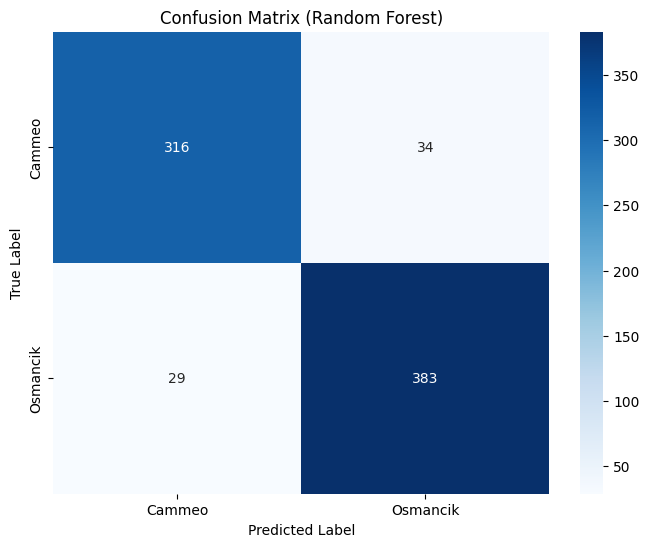

In [8]:
# 5. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix (Random Forest)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

/tmp/ipython-input-431108893.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_imp_df, palette='viridis')


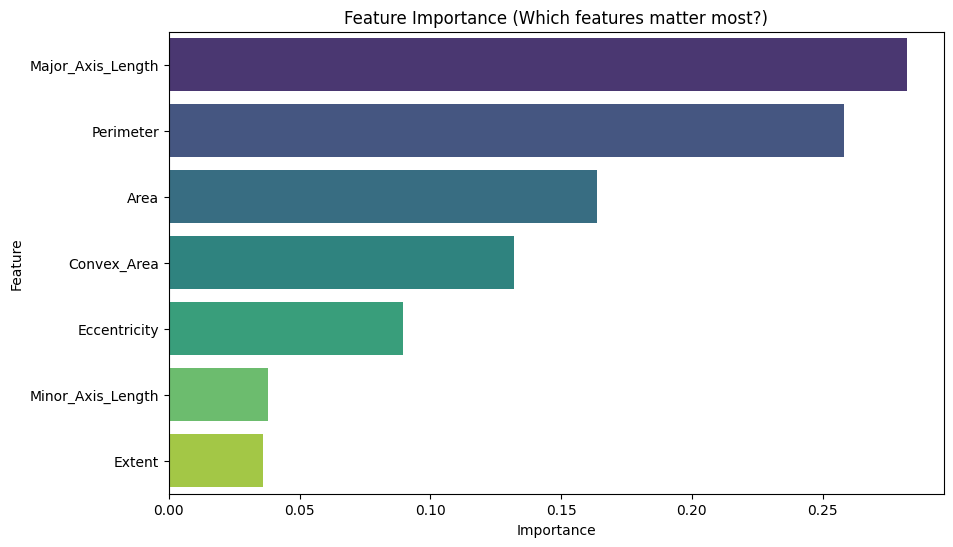

In [9]:
# 6. Feature Importance
importances = rf_clf.feature_importances_
feature_names = X.columns
feature_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_imp_df = feature_imp_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_imp_df, palette='viridis')
plt.title('Feature Importance (Which features matter most?)')
plt.show()

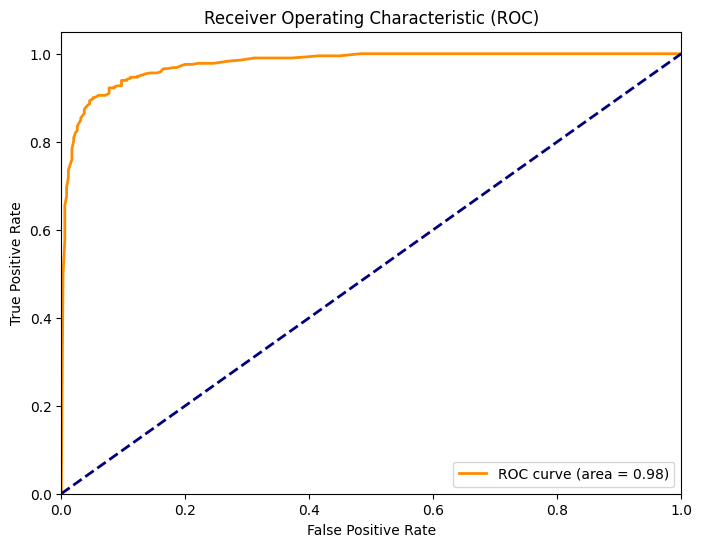

In [10]:
# 7. ROC and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()

In [11]:
# 8.Final output
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=target_names))
print("\nFeature Importance Ranking:")
print(feature_imp_df)

Accuracy: 0.9173

Classification Report:
              precision    recall  f1-score   support

      Cammeo       0.92      0.90      0.91       350
    Osmancik       0.92      0.93      0.92       412

    accuracy                           0.92       762
   macro avg       0.92      0.92      0.92       762
weighted avg       0.92      0.92      0.92       762


Feature Importance Ranking:
             Feature  Importance
2  Major_Axis_Length    0.282241
1          Perimeter    0.258371
0               Area    0.163847
5        Convex_Area    0.132159
4       Eccentricity    0.089427
3  Minor_Axis_Length    0.038031
6             Extent    0.035924
